# Homework 2: Functions, Merging & Visualization

This assignment synthesizes concepts from the Week 4 practice notebooks. Use the table below as a reference for where each function was introduced.

### **Concept Reference Map**

| Category | Concept / Function | Original Reference Notebook |
| :--- | :--- | :--- |
| **Data Exploration** | `info()`, `columns`, `unique()`, `head()` | `1-visualization_basics.ipynb` |
| **Statistics** | `describe()`, `mean()`, `pct_change()` | `1-visualization_basics.ipynb` |
| **Manipulation** | `rename()`, `query()`, `drop()`, `set_index()` | `1-visualization_basics.ipynb` / `2-merging_practice.ipynb` |
| **Aggregation** | `groupby()` | `1-visualization_basics.ipynb` |
| **Time Series** | `pd.to_datetime()`, `PeriodIndex` | `2-merging_practice.ipynb` |
| **Merging** | `pd.merge()`, `pd.concat()` | `2-merging_practice.ipynb` |
| **Visualization** | `plot()`, `scatter()`, `barh()` | `1-visualization_basics.ipynb` |

---

## A. Importing Data

Run the cell below to load the WorldBank API function and download population and GDP data for G7 countries.

In [692]:
import pandas as pd
import requests
import matplotlib.pyplot as plt

def get_wb_data(indicator, countries_list, start_year, end_year):
    country_str = ';'.join(countries_list)
    url = f'https://api.worldbank.org/v2/country/{country_str}/indicator/{indicator}?date={start_year}:{end_year}&format=json&per_page=1000'
    response = requests.get(url)
    data = response.json()[1]
    df = pd.json_normalize(data)
    return df[['countryiso3code', 'date', 'value']]

## A.1 Show info

In [693]:
# CREATE Country list of G7 countries using ISO3 Codes
g7 = ['USA', 'CAN', 'GBR', 'FRA', 'DEU', 'ITA', 'JPN']

In [694]:
inflation_df = get_wb_data('FP.CPI.TOTL.ZG', g7, 2000, 2025)
inflation_df

# YOUR CODE HERE

,countryiso3code,date,value
0,CAN,2025,NaN
1,CAN,2024,2.381584
2,CAN,2023,3.879002
3,CAN,2022,6.802801
4,CAN,2021,3.395193
...,...,...,...
177,USA,2004,2.677237
178,USA,2003,2.270095
179,USA,2002,1.586032
180,USA,2001,2.826171


## A.2 Show column names


In [695]:
# YOUR CODE HERE
print(inflation_df.columns)
print(inflation_df.info)

Index(['countryiso3code', 'date', 'value'], dtype='object')
<bound method DataFrame.info of     countryiso3code  date     value
0               CAN  2025       NaN
1               CAN  2024  2.381584
2               CAN  2023  3.879002
3               CAN  2022  6.802801
4               CAN  2021  3.395193
..              ...   ...       ...
177             USA  2004  2.677237
178             USA  2003  2.270095
179             USA  2002  1.586032
180             USA  2001  2.826171
181             USA  2000  3.376857

[182 rows x 3 columns]>


## A.3 Show unique countries

In [696]:
# YOUR CODE HERE
print(inflation_df['countryiso3code'].unique())

['CAN' 'DEU' 'FRA' 'GBR' 'ITA' 'JPN' 'USA']


# 1. Show GDP Growth for Japan using above data

## 1.A Rename column for country and value

In [697]:
# Rename country and value columns
# YOUR CODE HERE
country_dictionary = {
    'USA': 'United States',
    'CAN': 'Canada',
    'GBR': 'United Kingdom',
    'FRA': 'France',
    'DEU': 'Germany',
    'ITA': 'Italy',
    'JPN': 'Japan'
}
inflation_df = inflation_df.rename(columns={'countryiso3code': 'Country', 'value': 'Inflation Rate','date': 'Year'}).dropna()
inflation_df = inflation_df.set_index('Year')
inflation_df = inflation_df.replace({'Country': country_dictionary})
inflation_df

,Country,Inflation Rate
Year,,
2024,Canada,2.381584
2023,Canada,3.879002
2022,Canada,6.802801
2021,Canada,3.395193
2020,Canada,0.717000
...,...,...
2004,United States,2.677237
2003,United States,2.270095
2002,United States,1.586032


## 1.1 Create new data with only Japan

In [698]:
# Query japan
# YOUR CODE HERE
df_jp = inflation_df.query('Country == "Japan"')
df_jp

,Country,Inflation Rate
Year,,
2024,Japan,2.738537
2023,Japan,3.268134
2022,Japan,2.497703
2021,Japan,-0.233353
2020,Japan,-0.024996
2019,Japan,0.468776
2018,Japan,0.989095
2017,Japan,0.484200
2016,Japan,-0.127259


## 1.2 Set index as date, sort index, and drop country column

In [699]:
# Set index 
# YOUR CODE HERE
df_jp = df_jp.sort_index()
df_jp

,Country,Inflation Rate
Year,,
2000,Japan,-0.676579
2001,Japan,-0.740056
2002,Japan,-0.923494
2003,Japan,-0.256542
2004,Japan,-0.008573
2005,Japan,-0.282946
2006,Japan,0.249355
2007,Japan,0.060039
2008,Japan,1.380079


In [700]:
# DROP country column
# YOUR CODE HERE 
df_jp = df_jp.drop(['Country'], axis=1).rename(columns={'Inflation Rate': 'Inflation Rate in Japan'})
df_jp

,Inflation Rate in Japan
Year,
2000,-0.676579
2001,-0.740056
2002,-0.923494
2003,-0.256542
2004,-0.008573
2005,-0.282946
2006,0.249355
2007,0.060039
2008,1.380079


In [701]:
# Sort index makes it so date is descending
# YOUR CODE HERE 
df_jp.head(2)

,Inflation Rate in Japan
Year,
2000,-0.676579
2001,-0.740056


## 1.3 Plot

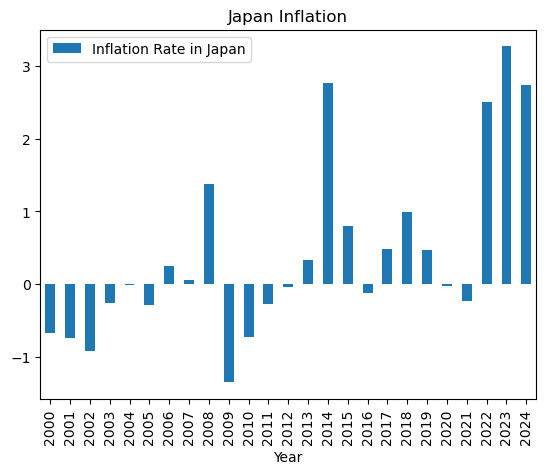

In [702]:
# Your code here
df_jp.plot(kind='bar')
plt.title("Japan Inflation");

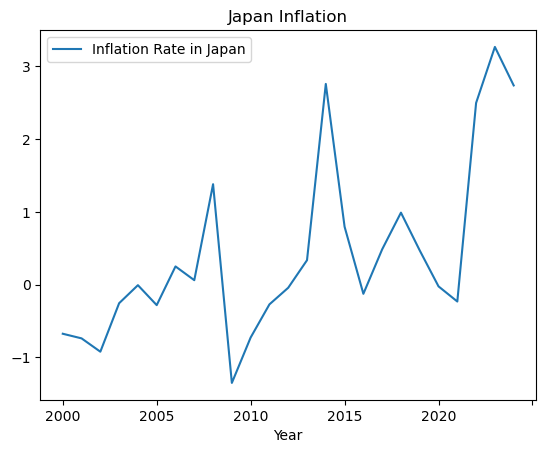

In [703]:
df_jp.plot(kind='line')
plt.title("Japan Inflation");

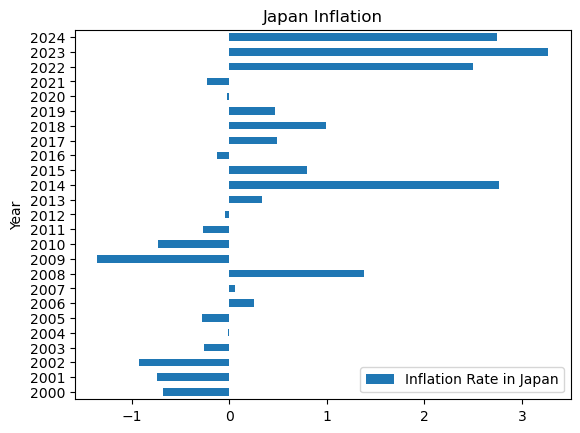

In [704]:
df_jp.plot(kind='barh')
plt.title("Japan Inflation");

In [705]:
df_jp_describe = df_jp.describe()
df_jp_describe

,Inflation Rate in Japan
count,25.000000
mean,0.414163
std,1.231592
min,-1.352837
25%,-0.272456
50%,-0.008573
75%,0.795280
max,3.268134


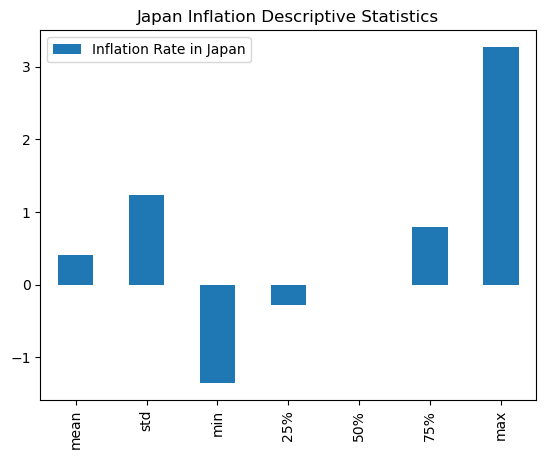

In [706]:
df_jp_describe.drop(('count')).plot(kind='bar')
plt.title("Japan Inflation Descriptive Statistics");

# 2. Merging Data
## 2.A Importing data

In [707]:
df_gdp = pd.read_csv("../../../data/hw/hw_2/eichengreen_1.csv")
df_gdp.head(2)

,economy,date,country,gdp_pc_ppp,gdp_ppp,ir_spread,cred_priv_sec,bureaucracy_qual,corruption,investment_profile,law_order,exchange_rate,sd_interbank
0,BR,1997,Brunei,63095.776415,19683.232219,NaN,NaN,3.291667,4.000000,9.750000,6.0,0.020075,NaN
1,BR,1998,Brunei,62020.909406,19793.601111,NaN,NaN,3.000000,3.583333,7.583333,6.0,0.039924,NaN


In [708]:
df_govt_bond = pd.read_csv("../../../data/hw/hw_2/eichengreen_2.csv")
df_govt_bond

,economy,date,country,net_borrow,kai,kao,bank_con,legor_uk,dist_eq,bond_market_cap,bo_plbn_scaled,bo_siln_scaled,bo_pabr_scaled,bo_siar_scaled
0,BR,1997,Brunei,11.062,0.10,0.0,NaN,NaN,500.529999,NaN,NaN,NaN,NaN,NaN
1,BR,1998,Brunei,14.424,0.10,0.0,NaN,NaN,500.529999,NaN,NaN,NaN,NaN,NaN
2,BR,1999,Brunei,28.624,0.10,0.0,NaN,NaN,500.529999,NaN,NaN,NaN,NaN,NaN
3,BR,2000,Brunei,20.701,0.10,0.0,NaN,NaN,500.529999,NaN,NaN,NaN,NaN,NaN
4,BR,2001,Brunei,-6.860,0.10,0.0,NaN,NaN,500.529999,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
317,VN,2015,Vietnam,6.290,0.85,0.9,50.49805,0.0,2338.550049,24.13,0.041442,0.041442,0.041442,0.041442
318,VN,2016,Vietnam,6.437,0.85,0.9,40.71964,0.0,2338.550049,36.91,0.027093,0.027093,0.027093,0.027093
319,VN,2017,Vietnam,3.859,0.85,0.9,25.88430,0.0,2338.550049,37.59,0.026603,0.026603,0.026603,0.026603
320,VN,2018,Vietnam,4.720,NaN,NaN,NaN,0.0,2338.550049,39.11,NaN,NaN,NaN,NaN


## 2.1 Filter one country

In [ ]:
print(df_govt_bond.economy.unique())
df_govt_bond_jp = df_govt_bond.query('economy == "JP"')
df_govt_bond_jp.head(2)

['BR' 'CN' 'HK' 'ID' 'JP' 'KH' 'KR' 'LA' 'MM' 'MY' 'PH' 'SG' 'TH' 'VN']


,economy,date,country,net_borrow,kai,kao,bank_con,legor_uk,dist_eq,bond_market_cap,bo_plbn_scaled,bo_siln_scaled,bo_pabr_scaled,bo_siar_scaled
92,JP,1997,Japan,4.985,0.0,0.0,32.52925,0.0,3969.73999,NaN,NaN,NaN,NaN,NaN
93,JP,1998,Japan,3.596,0.1,0.0,33.28231,0.0,3969.73999,83.0,0.0,0.0,0.0,0.0


In [710]:
#MAKE SURE YOU query df_govt_bond
df_govt_bond_vn = df_govt_bond.query('economy == "VN"')
df_govt_bond_vn.head(2)

,economy,date,country,net_borrow,kai,kao,bank_con,legor_uk,dist_eq,bond_market_cap,bo_plbn_scaled,bo_siln_scaled,bo_pabr_scaled,bo_siar_scaled
299,VN,1997,Vietnam,NaN,1.000000,0.714286,84.50824,0.0,2338.550049,NaN,NaN,NaN,NaN,NaN
300,VN,1998,Vietnam,NaN,0.888889,1.000000,84.61529,0.0,2338.550049,NaN,NaN,NaN,NaN,NaN


In [711]:
#MAKE SURE YOU GET GDP Data df_gdp
df_gdp_vn = df_gdp.query('economy == "VN"')
df_gdp_vn.head(2)

,economy,date,country,gdp_pc_ppp,gdp_ppp,ir_spread,cred_priv_sec,bureaucracy_qual,corruption,investment_profile,law_order,exchange_rate,sd_interbank
299,VN,1997,Vietnam,1709.896773,131889.833685,5.904167,19.848841,2.0,2.416667,6.583333,5.0,0.013462,NaN
300,VN,1998,Vietnam,1805.815779,141062.581723,5.170000,20.123863,2.0,2.000000,5.166667,5.0,0.024974,NaN


## 2.2 Filter gdp_pc_pp and set date as index

In [712]:
df_gdppcpp_vn = df_gdp_vn[['date', 'gdp_pc_ppp']].set_index('date').dropna().sort_index()
df_gdppcpp_vn

,gdp_pc_ppp
date,
1997,1709.896773
1998,1805.815779
1999,1896.989470
2000,2048.363759
2001,2200.020240
2002,2353.000468
2003,2538.163204
2004,2777.246874
2005,3051.608497


In [713]:
df_govt_bond_vn = df_govt_bond_vn.set_index('date').dropna().sort_index()
df_govt_bond_vn.head(2)

,economy,country,net_borrow,kai,kao,bank_con,legor_uk,dist_eq,bond_market_cap,bo_plbn_scaled,bo_siln_scaled,bo_pabr_scaled,bo_siar_scaled
date,,,,,,,,,,,,,
2012,VN,Vietnam,1.147,0.85,0.9,40.39090,0.0,2338.550049,16.58,0.060314,0.060314,0.060314,0.060314
2013,VN,Vietnam,6.857,0.85,0.9,40.55388,0.0,2338.550049,19.00,0.052632,0.052632,0.052632,0.052632


## 2.3 Merge data

In [714]:
# NOTE I sorted index and drop na

df_merge = pd.merge(df_gdppcpp_vn, df_govt_bond_vn, left_index=True, right_index=True, how='inner')
df_merge.head(2)

,gdp_pc_ppp,economy,country,net_borrow,kai,kao,bank_con,legor_uk,dist_eq,bond_market_cap,bo_plbn_scaled,bo_siln_scaled,bo_pabr_scaled,bo_siar_scaled
date,,,,,,,,,,,,,,
2012,4949.131363,VN,Vietnam,1.147,0.85,0.9,40.39090,0.0,2338.550049,16.58,0.060314,0.060314,0.060314,0.060314
2013,5253.397519,VN,Vietnam,6.857,0.85,0.9,40.55388,0.0,2338.550049,19.00,0.052632,0.052632,0.052632,0.052632


In [715]:
# Move country to the first column
cols = ['country', 'economy'] + [col for col in df_merge.columns if col not in ['country', 'economy']]
df_merge = df_merge[cols]
df_merge.head(2)

,country,economy,gdp_pc_ppp,net_borrow,kai,kao,bank_con,legor_uk,dist_eq,bond_market_cap,bo_plbn_scaled,bo_siln_scaled,bo_pabr_scaled,bo_siar_scaled
date,,,,,,,,,,,,,,
2012,Vietnam,VN,4949.131363,1.147,0.85,0.9,40.39090,0.0,2338.550049,16.58,0.060314,0.060314,0.060314,0.060314
2013,Vietnam,VN,5253.397519,6.857,0.85,0.9,40.55388,0.0,2338.550049,19.00,0.052632,0.052632,0.052632,0.052632


## 2.4 Convert to datetime

In [716]:
# No code changes needed
df_merge.index = pd.to_datetime(df_merge.index, format = "%Y")
df_merge.head(2)

,country,economy,gdp_pc_ppp,net_borrow,kai,kao,bank_con,legor_uk,dist_eq,bond_market_cap,bo_plbn_scaled,bo_siln_scaled,bo_pabr_scaled,bo_siar_scaled
date,,,,,,,,,,,,,,
2012-01-01,Vietnam,VN,4949.131363,1.147,0.85,0.9,40.39090,0.0,2338.550049,16.58,0.060314,0.060314,0.060314,0.060314
2013-01-01,Vietnam,VN,5253.397519,6.857,0.85,0.9,40.55388,0.0,2338.550049,19.00,0.052632,0.052632,0.052632,0.052632


## 2.4 Plot net_borrow

Text(0, 0.5, '% GDP')

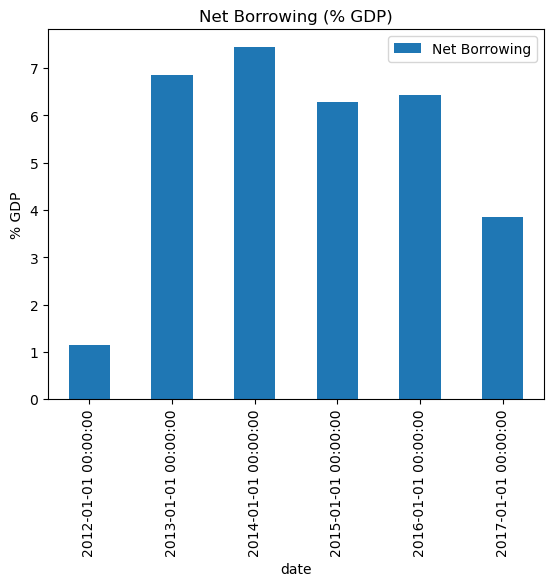

In [717]:
# Your code here
df_merge = df_merge.rename(columns={'net_borrow': 'Net Borrowing'})
df_merge.plot(y='Net Borrowing', kind='bar')
plt.title("Net Borrowing (% GDP)")
plt.ylabel("% GDP")

# 3. Functions

## 3.A Import Data

In [723]:
df_gdp = pd.read_csv("../../../data/hw/hw_2/eichengreen_1.csv")
df_govt_bond = pd.read_csv("../../../data/hw/hw_2/eichengreen_2.csv")
df_merge_all = pd.concat([df_gdp, df_govt_bond], axis = 'columns')
df_merge_all.columns

Index(['economy', 'date', 'country', 'gdp_pc_ppp', 'gdp_ppp', 'ir_spread',
       'cred_priv_sec', 'bureaucracy_qual', 'corruption', 'investment_profile',
       'law_order', 'exchange_rate', 'sd_interbank', 'economy', 'date',
       'country', 'net_borrow', 'kai', 'kao', 'bank_con', 'legor_uk',
       'dist_eq', 'bond_market_cap', 'bo_plbn_scaled', 'bo_siln_scaled',
       'bo_pabr_scaled', 'bo_siar_scaled'],
      dtype='object')

In [724]:
df_merge_all = pd.merge(df_gdp, df_govt_bond, on=['economy', 'date', 'country'])
df_merge_all.columns

Index(['economy', 'date', 'country', 'gdp_pc_ppp', 'gdp_ppp', 'ir_spread',
       'cred_priv_sec', 'bureaucracy_qual', 'corruption', 'investment_profile',
       'law_order', 'exchange_rate', 'sd_interbank', 'net_borrow', 'kai',
       'kao', 'bank_con', 'legor_uk', 'dist_eq', 'bond_market_cap',
       'bo_plbn_scaled', 'bo_siln_scaled', 'bo_pabr_scaled', 'bo_siar_scaled'],
      dtype='object')

## 3.1 Create function to conver to datetime

In [730]:
def convert_date(df):
    df = df.copy()
    df['date'] = pd.to_datetime(df['date'], format='%Y')
    return df

convert_date(df_gdp)

,economy,date,country,gdp_pc_ppp,gdp_ppp,ir_spread,cred_priv_sec,bureaucracy_qual,corruption,investment_profile,law_order,exchange_rate,sd_interbank
0,BR,1997-01-01,Brunei,63095.776415,19683.232219,NaN,NaN,3.291667,4.000000,9.750000,6.0,0.020075,NaN
1,BR,1998-01-01,Brunei,62020.909406,19793.601111,NaN,NaN,3.000000,3.583333,7.583333,6.0,0.039924,NaN
2,BR,1999-01-01,Brunei,63432.255561,20692.236087,NaN,60.176555,3.000000,3.000000,7.250000,6.0,0.014156,NaN
3,BR,2000-01-01,Brunei,65305.765574,21757.595387,NaN,50.293146,3.000000,3.000000,8.000000,6.0,0.009065,NaN
4,BR,2001-01-01,Brunei,67184.354498,22844.964797,NaN,53.633142,3.000000,2.666667,10.625000,6.0,0.019393,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
317,VN,2015-01-01,Vietnam,5989.757690,555113.228681,2.370000,111.926330,2.000000,2.500000,8.000000,4.0,0.003788,NaN
318,VN,2016-01-01,Vietnam,6365.289485,596037.585310,1.925000,123.814875,2.000000,2.500000,8.000000,4.0,0.002567,NaN
319,VN,2017-01-01,Vietnam,6857.984044,648742.261438,2.258333,130.721797,2.000000,2.166667,8.000000,4.0,0.001378,NaN
320,VN,2018-01-01,Vietnam,7447.814334,711567.123362,2.720389,133.135982,2.000000,2.375000,8.083333,4.0,0.001244,NaN


In [731]:
df_merge_all.head(1)

,economy,date,country,gdp_pc_ppp,gdp_ppp,ir_spread,cred_priv_sec,bureaucracy_qual,corruption,investment_profile,...,kai,kao,bank_con,legor_uk,dist_eq,bond_market_cap,bo_plbn_scaled,bo_siln_scaled,bo_pabr_scaled,bo_siar_scaled
0,BR,1997,Brunei,63095.776415,19683.232219,NaN,NaN,3.291667,4.0,9.75,...,0.1,0.0,NaN,NaN,500.529999,NaN,NaN,NaN,NaN,NaN


In [732]:
df_merge_all_converted = convert_date(df_merge_all)
df_merge_all_converted.head(1)

,economy,date,country,gdp_pc_ppp,gdp_ppp,ir_spread,cred_priv_sec,bureaucracy_qual,corruption,investment_profile,...,kai,kao,bank_con,legor_uk,dist_eq,bond_market_cap,bo_plbn_scaled,bo_siln_scaled,bo_pabr_scaled,bo_siar_scaled
0,BR,1997-01-01,Brunei,63095.776415,19683.232219,NaN,NaN,3.291667,4.0,9.75,...,0.1,0.0,NaN,NaN,500.529999,NaN,NaN,NaN,NaN,NaN


## 3.2 Rename column function

C:\Users\marti\AppData\Local\Temp\ipykernel_3568\1260434390.py:7: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  plt.scatter(df_plot['gdp_pc_ppp'].pct_change(1), df_plot['net_borrow'])


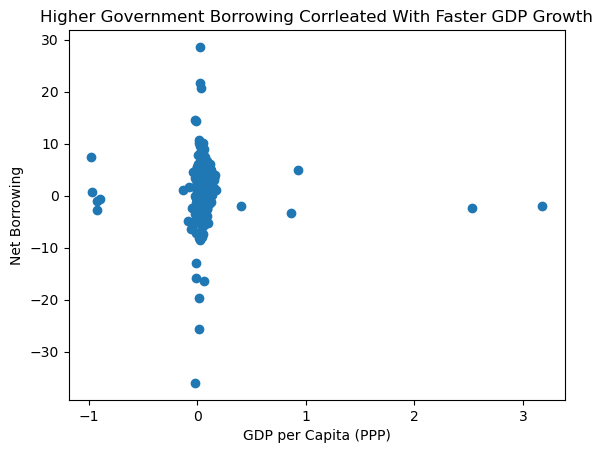

In [733]:
def plot_scatter(x_title, y_title, main_title):
    df_plot = df_merge_all_converted
    df_plot = df_plot.copy()

    
    # Define the columns for x and y
    plt.scatter(df_plot['gdp_pc_ppp'].pct_change(1), df_plot['net_borrow'])
    
    # Set labels and title
    plt.xlabel(x_title)
    plt.ylabel(y_title)
    plt.title(main_title)

# Note corrleation does not equal causation :)
plot_scatter('GDP per Capita (PPP)', 'Net Borrowing', 'Higher Government Borrowing Corrleated With Faster GDP Growth')